# RAG Pipeline Evaluation Analysis

Analyses the binary-judge evaluation results produced by `src/process/rag_pipeline.py`.

**What this notebook covers:**
1. Load & validate evaluation CSVs
2. Overall accuracy per strategy
3. Per-decile accuracy — popularity bias
4. Retrieval quality — Recall@K
5. Per-dataset breakdown
5b. Per-dataset × per-decile accuracy
6. Score distribution & reasoning inspection
7. Cross-strategy comparison
8. Export summary

In [13]:
from __future__ import annotations

import ast
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings("ignore")

# ── Repo root on path ─────────────────────────────────────────────────────────
# In a notebook __file__ is undefined; walk up from cwd (notebook is 2 levels deep)
_REPO_ROOT = Path.cwd()
while not (_REPO_ROOT / "config.py").exists() and _REPO_ROOT.parent != _REPO_ROOT:
    _REPO_ROOT = _REPO_ROOT.parent
if str(_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(_REPO_ROOT))

from config import DATA_DIR

print(f"DATA_DIR: {DATA_DIR}")

DATA_DIR: /Users/cyro/Documents/VSC/PopularityBias/data


## Configuration

Set `COLLECTION_NAME` and `OUTPUT_DIR` to match the `PipelineConfig` used when the pipeline was run.

In [14]:
# ── Match these to your PipelineConfig values ─────────────────────────────────
COLLECTION_NAME = "wiki_full_bil"
OUTPUT_DIR      = "evaluation_results_nq_turbo"
STRATEGIES      = ["approximation", "bm25"]
NUM_DECILES     = 10

RESULTS_DIR = Path(DATA_DIR) / COLLECTION_NAME / OUTPUT_DIR
print(f"Looking for results in: {RESULTS_DIR}")

# Confirm files exist
for s in STRATEGIES:
    p = RESULTS_DIR / f"evaluation_results_{s}.csv"
    status = "found" if p.exists() else "MISSING"
    print(f"  {p.name}: {status}")

Looking for results in: /Users/cyro/Documents/VSC/PopularityBias/data/wiki_full_bil/evaluation_results_nq_turbo
  evaluation_results_approximation.csv: found
  evaluation_results_bm25.csv: found


## 1. Load & Validate Results

In [15]:
def _parse_metadata(val) -> dict:
    """Parse the 'metadata' column, which may be a dict, a JSON string, or a Python repr."""
    if isinstance(val, dict):
        return val
    if isinstance(val, str):
        try:
            import json as _json
            return _json.loads(val)
        except Exception:
            pass
        try:
            return ast.literal_eval(val)
        except Exception:
            pass
    return {}


def _parse_id_list(val) -> list[int]:
    """Coerce a retrieved_doc_ids value to a list of ints.

    The field may arrive as:
      - already a list (e.g. [19367245])
      - a string repr  (e.g. "[19367245]")
    """
    if isinstance(val, list):
        return [int(v) for v in val]
    if isinstance(val, str):
        try:
            parsed = ast.literal_eval(val)
            if isinstance(parsed, list):
                return [int(v) for v in parsed]
        except Exception:
            pass
    return []


def load_results(strategy: str) -> pd.DataFrame:
    """Load and normalise an evaluation CSV for one strategy."""
    path = RESULTS_DIR / f"evaluation_results_{strategy}.csv"
    df = pd.read_csv(path)

    # Unpack metadata dict into flat columns
    meta = df["metadata"].apply(_parse_metadata)
    df["wikipedia_id"]      = meta.apply(lambda m: m.get("wikipedia_id"))
    df["decile"]            = meta.apply(lambda m: m.get("decile"))
    df["dataset"]           = meta.apply(lambda m: m.get("dataset", "unknown"))
    df["retrieved_doc_ids"] = meta.apply(lambda m: _parse_id_list(m.get("retrieved_doc_ids", [])))

    # Normalise wikipedia_id to int for consistent comparison
    df["wikipedia_id_int"] = pd.to_numeric(df["wikipedia_id"], errors="coerce")

    # Hit: is the target doc anywhere in the retrieved list?
    df["hit"] = df.apply(
        lambda r: int(r["wikipedia_id_int"]) in r["retrieved_doc_ids"]
        if pd.notna(r["wikipedia_id_int"]) and r["retrieved_doc_ids"]
        else False,
        axis=1,
    )

    # Normalise evaluation_score to bool
    df["correct"] = df["evaluation_score"].map(
        lambda v: bool(v) if not isinstance(v, str)
        else v.strip().lower() in {"true", "1", "yes"}
    )

    df["strategy"] = strategy
    return df


raw: dict[str, pd.DataFrame] = {}
for s in STRATEGIES:
    try:
        raw[s] = load_results(s)
        print(f"  {s}: {len(raw[s]):,} rows")
        has_ids = raw[s]["retrieved_doc_ids"].apply(bool).sum()
        print(f"    retrieved_doc_ids present in {has_ids:,} / {len(raw[s]):,} rows")
    except FileNotFoundError:
        print(f"  {s}: file not found — skipping")

LOADED = list(raw.keys())
assert LOADED, "No result files found — run src/process/rag_pipeline.py first."

# Combined view
combined = pd.concat(raw.values(), ignore_index=True)
print(f"\nTotal rows across all strategies: {len(combined):,}")
combined[["question", "wikipedia_id", "decile", "dataset", "retrieved_doc_ids", "hit", "correct", "strategy"]].head(3)

  approximation: 889 rows
    retrieved_doc_ids present in 889 / 889 rows
  bm25: 889 rows
    retrieved_doc_ids present in 889 / 889 rows

Total rows across all strategies: 1,778


,question,wikipedia_id,decile,dataset,retrieved_doc_ids,hit,correct,strategy
0,Jiří Kučný [SEP] sport,30880931,0,trex,[30880931],True,True,approximation
1,Herman D. Crow [SEP] occupation,45488244,0,trex,[45488244],True,True,approximation
2,Asteropetes [SEP] parent taxon,22153468,0,trex,[22153468],True,True,approximation


## 2. Overall Accuracy per Strategy

,n,n_correct,pct_correct,accuracy,ci95
strategy,,,,,
approximation,889,673,75.7%,0.75703,0.028193
bm25,889,679,76.4%,0.76378,0.027922


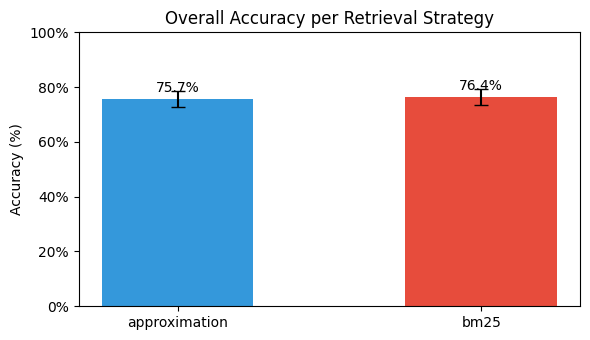

In [16]:
summary_rows = []
for s, df in raw.items():
    n       = len(df)
    n_true  = df["correct"].sum()
    acc     = n_true / n if n else float("nan")
    se      = np.sqrt(acc * (1 - acc) / n) if n else float("nan")
    summary_rows.append({
        "strategy":      s,
        "n":             n,
        "n_correct":     int(n_true),
        "accuracy":      acc,
        "ci95":          1.96 * se,
        "pct_correct":   f"{acc * 100:.1f}%",
    })

summary_df = pd.DataFrame(summary_rows).set_index("strategy")
display(summary_df[["n", "n_correct", "pct_correct", "accuracy", "ci95"]])

fig, ax = plt.subplots(figsize=(6, 3.5))
colors = ["#3498db" if s in ("approximation", "vector") else "#e74c3c" for s in summary_df.index]
bars = ax.bar(summary_df.index, summary_df["accuracy"] * 100, color=colors,
              yerr=summary_df["ci95"] * 100, capsize=5, width=0.5)
ax.set_ylabel("Accuracy (%)")
ax.set_title("Overall Accuracy per Retrieval Strategy")
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
for bar, row in zip(bars, summary_df.itertuples()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5,
            f"{row.accuracy * 100:.1f}%", ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "fig_overall_accuracy.png", dpi=150)
plt.show()

## 3. Per-Decile Accuracy — Popularity Bias

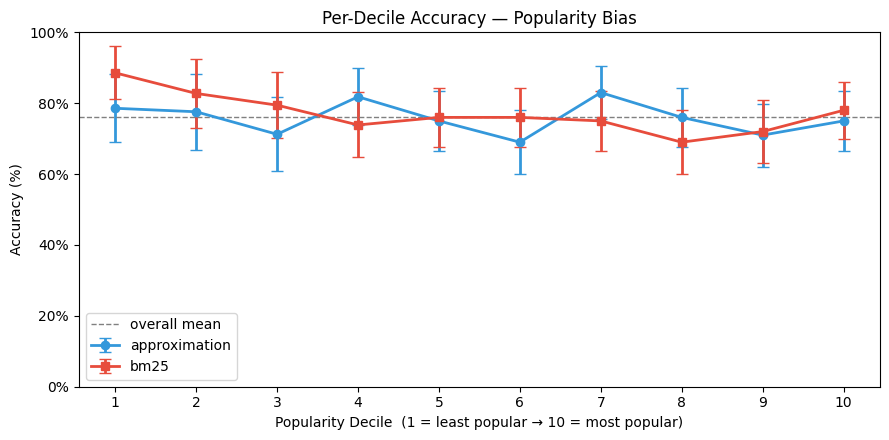


--- approximation ---


,accuracy,ci95,n
decile,,,
1,78.6%,±9.6%,70
2,77.6%,±10.7%,58
3,71.2%,±10.4%,73
4,81.8%,±8.1%,88
5,75.0%,±8.5%,100
6,69.0%,±9.1%,100
7,83.0%,±7.4%,100
8,76.0%,±8.4%,100
9,71.0%,±8.9%,100



--- bm25 ---


,accuracy,ci95,n
decile,,,
1,88.6%,±7.5%,70
2,82.8%,±9.7%,58
3,79.5%,±9.3%,73
4,73.9%,±9.2%,88
5,76.0%,±8.4%,100
6,76.0%,±8.4%,100
7,75.0%,±8.5%,100
8,69.0%,±9.1%,100
9,72.0%,±8.8%,100


In [17]:
strategy_colors = {
    "approximation": "#3498db",
    "vector":        "#3498db",
    "bm25":          "#e74c3c",
    "hybrid":        "#27ae60",
}
strategy_markers = {
    "approximation": "o",
    "vector":        "o",
    "bm25":          "s",
    "hybrid":        "D",
}

fig, ax = plt.subplots(figsize=(9, 4.5))

decile_tables: dict[str, pd.DataFrame] = {}

for s, df in raw.items():
    df_valid = df.dropna(subset=["decile"]).copy()
    df_valid["decile"] = df_valid["decile"].astype(int)

    rows = []
    for d in range(NUM_DECILES):
        sub  = df_valid[df_valid["decile"] == d]
        n    = len(sub)
        if n == 0:
            rows.append({"decile": d + 1, "accuracy": np.nan, "ci95": np.nan, "n": 0})
            continue
        acc  = sub["correct"].mean()
        se   = np.sqrt(acc * (1 - acc) / n) if n > 1 else 0.0
        rows.append({"decile": d + 1, "accuracy": acc, "ci95": 1.96 * se, "n": n})

    dt = pd.DataFrame(rows)
    decile_tables[s] = dt

    color  = strategy_colors.get(s, "#888")
    marker = strategy_markers.get(s, "o")
    ax.errorbar(
        dt["decile"], dt["accuracy"] * 100,
        yerr=dt["ci95"] * 100,
        label=s, color=color, marker=marker,
        linewidth=2, markersize=6, capsize=4,
    )

ax.set_xlabel("Popularity Decile  (1 = least popular → 10 = most popular)")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Per-Decile Accuracy — Popularity Bias")
ax.set_xticks(range(1, NUM_DECILES + 1))
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.axhline(combined["correct"].mean() * 100, color="grey", linestyle="--",
           linewidth=1, label="overall mean")
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "fig_decile_accuracy.png", dpi=150)
plt.show()

# Print table
for s, dt in decile_tables.items():
    print(f"\n--- {s} ---")
    display(dt.set_index("decile").style.format({"accuracy": "{:.1%}", "ci95": "±{:.1%}", "n": "{:,.0f}"}))

## 4. Retrieval Quality — Recall@K

Uses `retrieved_doc_ids` from the result metadata to check whether the target
document (`wikipedia_id`) appeared in the retrieved set — independently of
whether the LLM answer was judged correct.

* **Hit@K** — 1 if the target doc is among the top-K retrieved IDs, else 0.  
  Because the pipeline writes all retrieved IDs into `retrieved_doc_ids`, hit
  is computed directly from that list (no re-truncation at K needed unless you
  want to simulate lower K values).  
* **Per-decile Recall** — shows whether the retriever surfaces documents from
  less-popular deciles as reliably as popular ones.

,n,hits,pct_hit,recall,ci95
strategy,,,,,
approximation,889,334,37.6%,0.375703,0.031836
bm25,889,284,31.9%,0.319460,0.030651


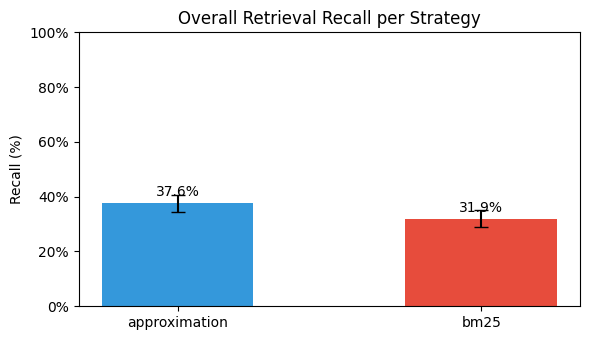

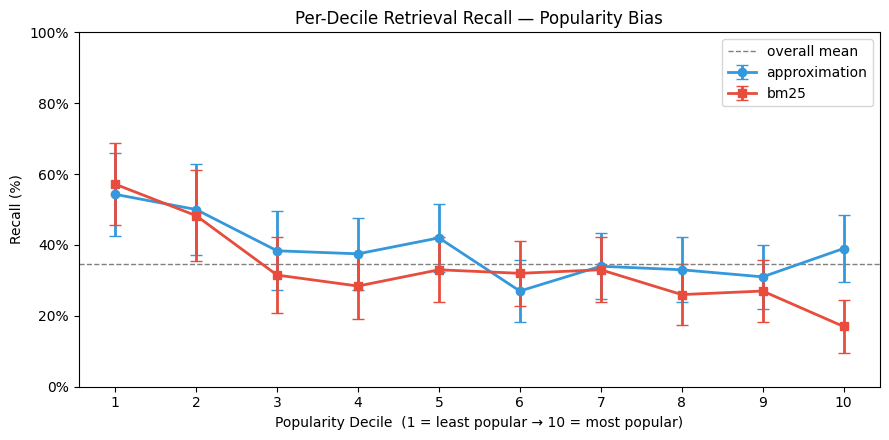

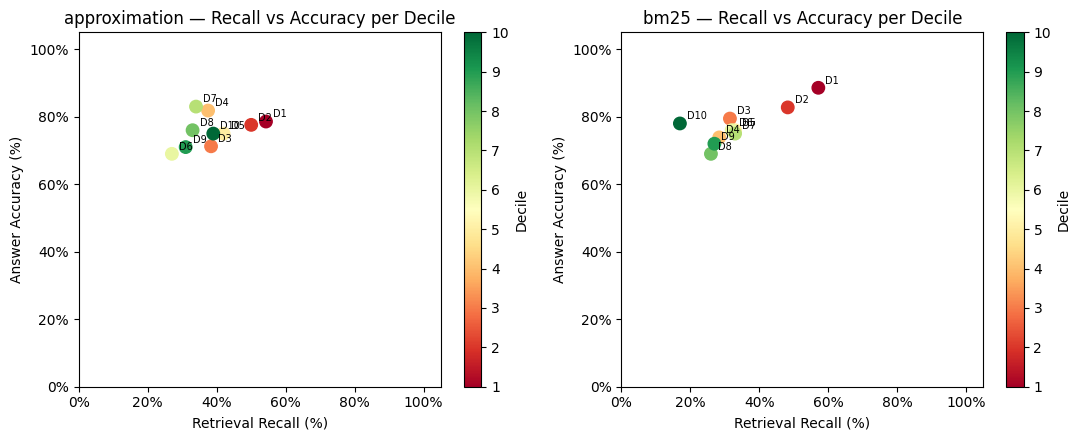


--- approximation ---


,recall,ci95,n
decile,,,
1,54.3%,±11.7%,70
2,50.0%,±12.9%,58
3,38.4%,±11.2%,73
4,37.5%,±10.1%,88
5,42.0%,±9.7%,100
6,27.0%,±8.7%,100
7,34.0%,±9.3%,100
8,33.0%,±9.2%,100
9,31.0%,±9.1%,100



--- bm25 ---


,recall,ci95,n
decile,,,
1,57.1%,±11.6%,70
2,48.3%,±12.9%,58
3,31.5%,±10.7%,73
4,28.4%,±9.4%,88
5,33.0%,±9.2%,100
6,32.0%,±9.1%,100
7,33.0%,±9.2%,100
8,26.0%,±8.6%,100
9,27.0%,±8.7%,100


In [18]:
# ── Retrieval hit rate ────────────────────────────────────────────────────────

# Overall hit rate per strategy
retrieval_summary_rows = []
for s, df in raw.items():
    has_ids = df["retrieved_doc_ids"].apply(bool).sum()
    if has_ids == 0:
        print(f"[{s}] No retrieved_doc_ids found in metadata — skipping retrieval analysis.")
        print("      Make sure the pipeline writes 'retrieved_doc_ids' into the metadata dict.")
        continue
    n    = len(df)
    hits = df["hit"].sum()
    rate = hits / n if n else float("nan")
    se   = np.sqrt(rate * (1 - rate) / n) if n else float("nan")
    retrieval_summary_rows.append({
        "strategy":  s,
        "n":         n,
        "hits":      int(hits),
        "recall": rate,
        "ci95":      1.96 * se,
        "pct_hit":   f"{rate * 100:.1f}%",
    })

if not retrieval_summary_rows:
    print("No retrieval data available — section skipped.")
else:
    ret_summary_df = pd.DataFrame(retrieval_summary_rows).set_index("strategy")
    display(ret_summary_df[["n", "hits", "pct_hit", "recall", "ci95"]])

    # ── Bar chart: overall retrieval recall ───────────────────────────────────
    fig, ax = plt.subplots(figsize=(6, 3.5))
    colors = [strategy_colors.get(s, "#888") for s in ret_summary_df.index]
    bars = ax.bar(
        ret_summary_df.index, ret_summary_df["recall"] * 100,
        color=colors, yerr=ret_summary_df["ci95"] * 100,
        capsize=5, width=0.5,
    )
    ax.set_ylabel("Recall (%)")
    ax.set_title("Overall Retrieval Recall per Strategy")
    ax.set_ylim(0, 100)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    for bar, row in zip(bars, ret_summary_df.itertuples()):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1.5,
            f"{row.recall * 100:.1f}%",
            ha="center", va="bottom", fontsize=10,
        )
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "fig_retrieval_recall.png", dpi=150)
    plt.show()

    # ── Per-decile retrieval recall ───────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(9, 4.5))
    decile_recall_tables: dict[str, pd.DataFrame] = {}

    for s, df in raw.items():
        if not df["retrieved_doc_ids"].apply(bool).sum():
            continue
        df_valid = df.dropna(subset=["decile"]).copy()
        df_valid["decile"] = df_valid["decile"].astype(int)

        rows = []
        for d in range(NUM_DECILES):
            sub = df_valid[df_valid["decile"] == d]
            n   = len(sub)
            if n == 0:
                rows.append({"decile": d + 1, "recall": np.nan, "ci95": np.nan, "n": 0})
                continue
            rate = sub["hit"].mean()
            se   = np.sqrt(rate * (1 - rate) / n) if n > 1 else 0.0
            rows.append({"decile": d + 1, "recall": rate, "ci95": 1.96 * se, "n": n})

        drt = pd.DataFrame(rows)
        decile_recall_tables[s] = drt

        color  = strategy_colors.get(s, "#888")
        marker = strategy_markers.get(s, "o")
        ax.errorbar(
            drt["decile"], drt["recall"] * 100,
            yerr=drt["ci95"] * 100,
            label=s, color=color, marker=marker,
            linewidth=2, markersize=6, capsize=4,
        )

    ax.set_xlabel("Popularity Decile  (1 = least popular \u2192 10 = most popular)")
    ax.set_ylabel("Recall (%)")
    ax.set_title("Per-Decile Retrieval Recall — Popularity Bias")
    ax.set_xticks(range(1, NUM_DECILES + 1))
    ax.set_ylim(0, 100)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    if decile_recall_tables:
        overall_hit = combined[combined["retrieved_doc_ids"].apply(bool)]["hit"].mean()
        ax.axhline(overall_hit * 100, color="grey", linestyle="--",
                   linewidth=1, label="overall mean")
    ax.legend()
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "fig_decile_recall.png", dpi=150)
    plt.show()

    # ── Accuracy vs retrieval recall scatter ──────────────────────────────────
    # Shows whether correct answers require a retrieval hit, or the LLM can
    # recover even when the wrong document is retrieved.
    fig, axes = plt.subplots(1, len(decile_recall_tables), figsize=(5.5 * len(decile_recall_tables), 4.5))
    if len(decile_recall_tables) == 1:
        axes = [axes]

    for ax, (s, drt) in zip(axes, decile_recall_tables.items()):
        dt = decile_tables.get(s)
        if dt is None:
            continue
        merged_d = drt.merge(dt, on="decile", suffixes=("_recall", "_acc"))
        sc = ax.scatter(
            merged_d["recall"] * 100,
            merged_d["accuracy"] * 100,
            c=merged_d["decile"],
            cmap="RdYlGn", s=80, zorder=3,
        )
        for _, row in merged_d.iterrows():
            ax.annotate(
                f"D{int(row['decile'])}",
                (row["recall"] * 100, row["accuracy"] * 100),
                textcoords="offset points", xytext=(5, 3), fontsize=7,
            )
        ax.set_xlabel("Retrieval Recall (%)")
        ax.set_ylabel("Answer Accuracy (%)")
        ax.set_title(f"{s} — Recall vs Accuracy per Decile")
        ax.set_xlim(0, 105)
        ax.set_ylim(0, 105)
        ax.xaxis.set_major_formatter(mticker.PercentFormatter())
        ax.yaxis.set_major_formatter(mticker.PercentFormatter())
        plt.colorbar(sc, ax=ax, label="Decile")

    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "fig_recall_vs_accuracy.png", dpi=150)
    plt.show()

    # ── Per-decile recall tables ──────────────────────────────────────────────
    for s, drt in decile_recall_tables.items():
        print(f"\n--- {s} ---")
        display(
            drt.set_index("decile").style.format(
                {"recall": "{:.1%}", "ci95": "\u00b1{:.1%}", "n": "{:,.0f}"}
            )
        )

## 5. Per-Dataset Breakdown

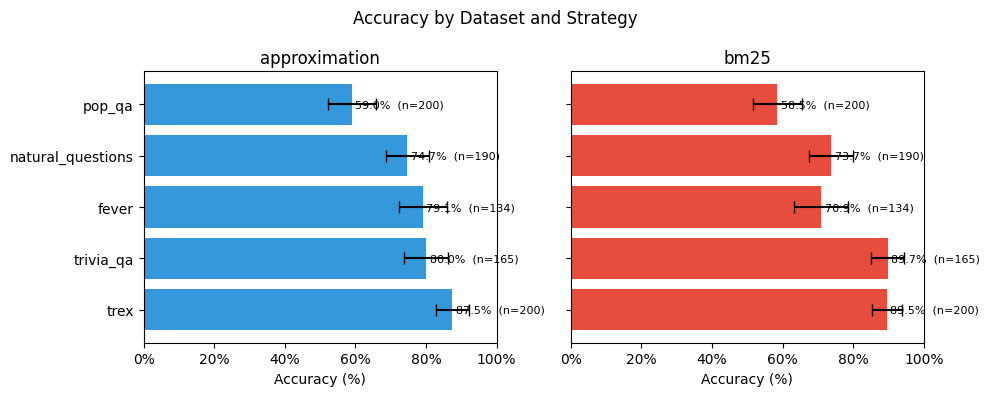

strategy,approximation,bm25
dataset,,
fever,79.1%,70.9%
natural_questions,74.7%,73.7%
pop_qa,59.0%,58.5%
trex,87.5%,89.5%
trivia_qa,80.0%,89.7%


In [19]:
dataset_rows = []
for s, df in raw.items():
    for ds, sub in df.groupby("dataset"):
        n   = len(sub)
        acc = sub["correct"].mean()
        se  = np.sqrt(acc * (1 - acc) / n) if n > 1 else 0.0
        dataset_rows.append({
            "strategy": s,
            "dataset":  ds,
            "n":        n,
            "accuracy": acc,
            "ci95":     1.96 * se,
        })

ds_df = pd.DataFrame(dataset_rows)
datasets = ds_df["dataset"].unique()

if len(datasets) > 1:
    fig, axes = plt.subplots(1, len(LOADED), figsize=(5 * len(LOADED), 4), sharey=True)
    if len(LOADED) == 1:
        axes = [axes]
    for ax, s in zip(axes, LOADED):
        sub = ds_df[ds_df["strategy"] == s].sort_values("accuracy", ascending=False)
        bars = ax.barh(sub["dataset"], sub["accuracy"] * 100,
                       xerr=sub["ci95"] * 100, capsize=4,
                       color=strategy_colors.get(s, "#888"))
        ax.set_title(s)
        ax.set_xlabel("Accuracy (%)")
        ax.xaxis.set_major_formatter(mticker.PercentFormatter())
        ax.set_xlim(0, 100)
        for bar, row in zip(bars, sub.itertuples()):
            ax.text(row.accuracy * 100 + 1, bar.get_y() + bar.get_height() / 2,
                    f"{row.accuracy * 100:.1f}%  (n={row.n:,})",
                    va="center", fontsize=8)
    fig.suptitle("Accuracy by Dataset and Strategy", fontsize=12)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "fig_dataset_accuracy.png", dpi=150)
    plt.show()
else:
    print(f"Only one dataset ({datasets[0]}) — skipping grouped chart.")

display(
    ds_df.pivot_table(index="dataset", columns="strategy", values="accuracy")
    .style.format("{:.1%}")
    .set_caption("Accuracy by Dataset × Strategy")
)

## 5b. Per-Dataset × Per-Decile Accuracy

Same popularity-bias curve as section 3, but split by source dataset.
Each subplot shows one dataset; strategy lines are overlaid.

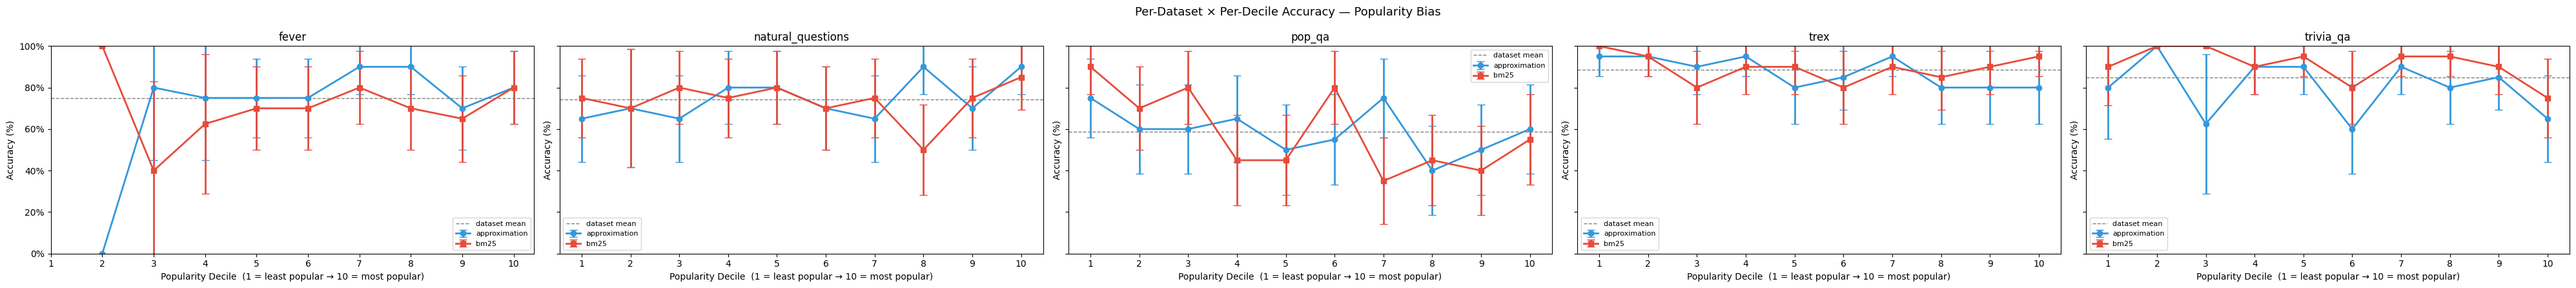


=== Dataset: fever ===

--- approximation ---


,accuracy,ci95,n
decile,,,
1,nan%,±nan%,0
2,0.0%,±0.0%,1
3,80.0%,±35.1%,5
4,75.0%,±30.0%,8
5,75.0%,±19.0%,20
6,75.0%,±19.0%,20
7,90.0%,±13.1%,20
8,90.0%,±13.1%,20
9,70.0%,±20.1%,20



--- bm25 ---


,accuracy,ci95,n
decile,,,
1,nan%,±nan%,0
2,100.0%,±0.0%,1
3,40.0%,±42.9%,5
4,62.5%,±33.5%,8
5,70.0%,±20.1%,20
6,70.0%,±20.1%,20
7,80.0%,±17.5%,20
8,70.0%,±20.1%,20
9,65.0%,±20.9%,20



=== Dataset: natural_questions ===

--- approximation ---


...


=== Dataset: trivia_qa ===

--- approximation ---


,accuracy,ci95,n
decile,,,
1,80.0%,±24.8%,10
2,100.0%,±0.0%,7
3,62.5%,±33.5%,8
4,90.0%,±13.1%,20
5,90.0%,±13.1%,20
6,60.0%,±21.5%,20
7,90.0%,±13.1%,20
8,80.0%,±17.5%,20
9,85.0%,±15.6%,20



--- bm25 ---


,accuracy,ci95,n
decile,,,
1,90.0%,±18.6%,10
2,100.0%,±0.0%,7
3,100.0%,±0.0%,8
4,90.0%,±13.1%,20
5,95.0%,±9.6%,20
6,80.0%,±17.5%,20
7,95.0%,±9.6%,20
8,95.0%,±9.6%,20
9,90.0%,±13.1%,20


Saved: /Users/cyro/Documents/VSC/PopularityBias/data/wiki_full_bil/evaluation_results_nq_turbo/summary_decile_approximation_fever.csv
Saved: /Users/cyro/Documents/VSC/PopularityBias/data/wiki_full_bil/evaluation_results_nq_turbo/summary_decile_bm25_fever.csv
Saved: /Users/cyro/Documents/VSC/PopularityBias/data/wiki_full_bil/evaluation_results_nq_turbo/summary_decile_approximation_natural_questions.csv
Saved: /Users/cyro/Documents/VSC/PopularityBias/data/wiki_full_bil/evaluation_results_nq_turbo/summary_decile_bm25_natural_questions.csv
Saved: /Users/cyro/Documents/VSC/PopularityBias/data/wiki_full_bil/evaluation_results_nq_turbo/summary_decile_approximation_pop_qa.csv
Saved: /Users/cyro/Documents/VSC/PopularityBias/data/wiki_full_bil/evaluation_results_nq_turbo/summary_decile_bm25_pop_qa.csv
Saved: /Users/cyro/Documents/VSC/PopularityBias/data/wiki_full_bil/evaluation_results_nq_turbo/summary_decile_approximation_trex.csv
Saved: /Users/cyro/Documents/VSC/PopularityBias/data/wiki_full_b

In [20]:
datasets_present = sorted(combined["dataset"].dropna().unique())

if len(datasets_present) <= 1:
    print(f"Only one dataset ({datasets_present[0] if datasets_present else 'none'}) — per-dataset decile chart skipped.")
else:
    ncols = len(datasets_present)
    fig, axes = plt.subplots(1, ncols, figsize=(8 * ncols, 4.5), sharey=True)
    if ncols == 1:
        axes = [axes]

    ds_decile_tables: dict[tuple, pd.DataFrame] = {}

    for ax, ds in zip(axes, datasets_present):
        for s, df in raw.items():
            df_ds = df[df["dataset"] == ds].dropna(subset=["decile"]).copy()
            df_ds["decile"] = df_ds["decile"].astype(int)

            rows = []
            for d in range(NUM_DECILES):
                sub = df_ds[df_ds["decile"] == d]
                n   = len(sub)
                if n == 0:
                    rows.append({"decile": d + 1, "accuracy": np.nan, "ci95": np.nan, "n": 0})
                    continue
                acc = sub["correct"].mean()
                se  = np.sqrt(acc * (1 - acc) / n) if n > 1 else 0.0
                rows.append({"decile": d + 1, "accuracy": acc, "ci95": 1.96 * se, "n": n})

            dt = pd.DataFrame(rows)
            ds_decile_tables[(ds, s)] = dt

            color  = strategy_colors.get(s, "#888")
            marker = strategy_markers.get(s, "o")
            ax.errorbar(
                dt["decile"], dt["accuracy"] * 100,
                yerr=dt["ci95"] * 100,
                label=s, color=color, marker=marker,
                linewidth=2, markersize=6, capsize=4,
            )

        ds_mean = combined[combined["dataset"] == ds]["correct"].mean()
        ax.axhline(ds_mean * 100, color="grey", linestyle="--", linewidth=1, label="dataset mean")
        ax.set_title(ds)
        ax.set_xlabel("Popularity Decile  (1 = least popular \u2192 10 = most popular)")
        ax.set_ylabel("Accuracy (%)")
        ax.set_xticks(range(1, NUM_DECILES + 1))
        ax.set_ylim(0, 100)
        ax.yaxis.set_major_formatter(mticker.PercentFormatter())
        ax.legend(fontsize=8)

    fig.suptitle("Per-Dataset × Per-Decile Accuracy — Popularity Bias", fontsize=13)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "fig_dataset_decile_accuracy.png", dpi=150)
    plt.show()

    # Tables
    for ds in datasets_present:
        print(f"\n=== Dataset: {ds} ===")
        for s in LOADED:
            key = (ds, s)
            if key not in ds_decile_tables:
                continue
            print(f"\n--- {s} ---")
            display(
                ds_decile_tables[key].set_index("decile")
                .style.format({"accuracy": "{:.1%}", "ci95": "\u00b1{:.1%}", "n": "{:,.0f}"})
            )

    # Export CSVs
    for (ds, s), dt in ds_decile_tables.items():
        safe_ds = ds.replace("/", "_").replace(" ", "_")
        out = RESULTS_DIR / f"summary_decile_{s}_{safe_ds}.csv"
        dt.to_csv(out, index=False)
        print(f"Saved: {out}")

## 6. Score Distribution & Failure Mode Inspection

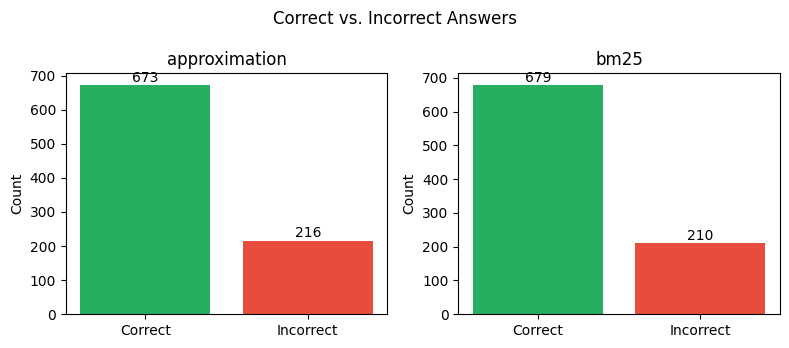

In [21]:
# --- 5a. Correct vs incorrect counts per strategy ---
fig, axes = plt.subplots(1, len(LOADED), figsize=(4 * len(LOADED), 3.5))
if len(LOADED) == 1:
    axes = [axes]

for ax, s in zip(axes, LOADED):
    vc = raw[s]["correct"].value_counts().reindex([True, False], fill_value=0)
    ax.bar(["Correct", "Incorrect"], vc.values,
           color=["#27ae60", "#e74c3c"])
    ax.set_title(s)
    ax.set_ylabel("Count")
    for i, v in enumerate(vc.values):
        ax.text(i, v + 0.5, str(v), ha="center", va="bottom", fontsize=10)

fig.suptitle("Correct vs. Incorrect Answers", fontsize=12)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "fig_score_distribution.png", dpi=150)
plt.show()

In [22]:
# --- 5b. Sample of failures (incorrect answers + judge reasoning) ---
N_SAMPLES = 5

for s, df in raw.items():
    failures = df[~df["correct"]].head(N_SAMPLES)
    if failures.empty:
        print(f"[{s}] No failures found.")
        continue
    print(f"\n{'='*70}")
    print(f" Strategy: {s}  ({len(df[~df['correct']]):,} failures total)")
    print(f"{'='*70}")
    for _, row in failures.iterrows():
        print(f"\n  Question  : {row['question'][:120]}")
        print(f"  Answer    : {str(row['proposed_answer'])[:120]}")
        print(f"  Reasoning : {str(row['reasoning'])[:200]}")
        print(f"  Decile    : {row.get('decile', '?')}  |  Dataset: {row.get('dataset', '?')}")


 Strategy: approximation  (216 failures total)

  Question  : Strange Disaster [SEP] performer
  Answer    :  The information provided does not specify a band named "Strange Disaster [SEP]". It mentions "A Natural Disaster" as an
  Reasoning : The proposed answer does not address the question about the performer related to 'Strange Disaster [SEP]' and instead discusses unrelated songs and albums, making it off-topic.
  Decile    : 0  |  Dataset: trex

  Question  : In what city was Anton Lui born?
  Answer    :  Anton Lui, who is a character in Lou Antonelli's science fiction stories, is not a real person. Therefore, there's no i
  Reasoning : The proposed answer does not directly address the question about the city where Anton Lui was born, instead focusing on the fictional nature of the character and providing unrelated information about 
  Decile    : 0  |  Dataset: pop_qa

  Question  : Who was the composer of Porch?
  Answer    :  The information provided is about Porcino, not Po

## 7. Cross-Strategy Comparison

For questions that appear in both strategy results, compare agreement.

Matched questions: 897
  Both correct  : 569  (63.4%)
  Only approximation  : 110  (12.3%)
  Only bm25           : 116  (12.9%)
  Neither       : 102  (11.4%)


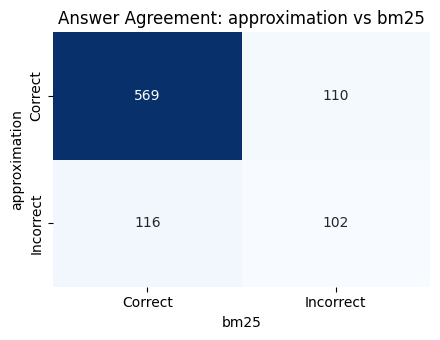

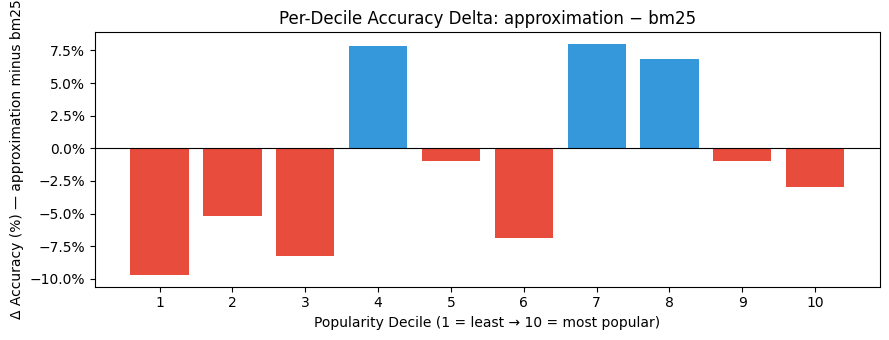

In [23]:
if len(LOADED) >= 2:
    s1, s2 = LOADED[0], LOADED[1]
    df1 = raw[s1][["question", "correct", "decile"]].rename(columns={"correct": f"correct_{s1}"})
    df2 = raw[s2][["question", "correct"]].rename(columns={"correct": f"correct_{s2}"})

    merged = df1.merge(df2, on="question", how="inner")
    total  = len(merged)

    both_correct   = ((merged[f"correct_{s1}"])  & (merged[f"correct_{s2}"])).sum()
    only_s1        = ((merged[f"correct_{s1}"])  & ~(merged[f"correct_{s2}"])).sum()
    only_s2        = (~(merged[f"correct_{s1}"]) & (merged[f"correct_{s2}"])).sum()
    neither        = (~(merged[f"correct_{s1}"]) & ~(merged[f"correct_{s2}"])).sum()

    print(f"Matched questions: {total:,}")
    print(f"  Both correct  : {both_correct:,}  ({both_correct/total:.1%})")
    print(f"  Only {s1:15s}: {only_s1:,}  ({only_s1/total:.1%})")
    print(f"  Only {s2:15s}: {only_s2:,}  ({only_s2/total:.1%})")
    print(f"  Neither       : {neither:,}  ({neither/total:.1%})")

    # Agreement heatmap
    ct = pd.crosstab(
        merged[f"correct_{s1}"].map({True: "Correct", False: "Incorrect"}),
        merged[f"correct_{s2}"].map({True: "Correct", False: "Incorrect"}),
        rownames=[s1], colnames=[s2],
    )
    fig, ax = plt.subplots(figsize=(4.5, 3.5))
    sns.heatmap(ct, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False)
    ax.set_title(f"Answer Agreement: {s1} vs {s2}")
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "fig_strategy_agreement.png", dpi=150)
    plt.show()

    # Per-decile delta (s1 accuracy minus s2 accuracy)
    delta_rows = []
    merged["decile"] = merged["decile"].dropna()
    for d in range(NUM_DECILES):
        sub = merged[merged["decile"] == d]
        if len(sub) == 0:
            continue
        delta = sub[f"correct_{s1}"].mean() - sub[f"correct_{s2}"].mean()
        delta_rows.append({"decile": d + 1, "delta": delta, "n": len(sub)})

    if delta_rows:
        delta_df = pd.DataFrame(delta_rows)
        fig, ax = plt.subplots(figsize=(9, 3.5))
        bar_colors = ["#3498db" if v >= 0 else "#e74c3c" for v in delta_df["delta"]]
        ax.bar(delta_df["decile"], delta_df["delta"] * 100, color=bar_colors)
        ax.axhline(0, color="black", linewidth=0.8)
        ax.set_xlabel("Popularity Decile (1 = least → 10 = most popular)")
        ax.set_ylabel(f"Δ Accuracy (%) — {s1} minus {s2}")
        ax.set_title(f"Per-Decile Accuracy Delta: {s1} − {s2}")
        ax.set_xticks(range(1, NUM_DECILES + 1))
        ax.yaxis.set_major_formatter(mticker.PercentFormatter())
        plt.tight_layout()
        plt.savefig(RESULTS_DIR / "fig_decile_delta.png", dpi=150)
        plt.show()
else:
    print("Only one strategy loaded — cross-strategy comparison skipped.")

## 8. Export Summary

In [24]:
# --- 8a. Overall accuracy summary CSV ---
summary_df.to_csv(RESULTS_DIR / "summary_overall.csv")
print(f"Saved: {RESULTS_DIR / 'summary_overall.csv'}")

# --- 8b. Per-decile accuracy CSVs ---
for s, dt in decile_tables.items():
    out = RESULTS_DIR / f"summary_decile_{s}.csv"
    dt.to_csv(out, index=False)
    print(f"Saved: {out}")

# --- 8c. Dataset breakdown CSV ---
ds_df.to_csv(RESULTS_DIR / "summary_datasets.csv", index=False)
print(f"Saved: {RESULTS_DIR / 'summary_datasets.csv'}")

# --- 8d. Retrieval recall summaries ---
if 'ret_summary_df' in dir():
    ret_summary_df.to_csv(RESULTS_DIR / "summary_retrieval_overall.csv")
    print(f"Saved: {RESULTS_DIR / 'summary_retrieval_overall.csv'}")

if 'decile_recall_tables' in dir():
    for s, drt in decile_recall_tables.items():
        out = RESULTS_DIR / f"summary_decile_recall_{s}.csv"
        drt.to_csv(out, index=False)
        print(f"Saved: {out}")

print("\nAll figures and summaries saved to:", RESULTS_DIR)

Saved: /Users/cyro/Documents/VSC/PopularityBias/data/wiki_full_bil/evaluation_results_nq_turbo/summary_overall.csv
Saved: /Users/cyro/Documents/VSC/PopularityBias/data/wiki_full_bil/evaluation_results_nq_turbo/summary_decile_approximation.csv
Saved: /Users/cyro/Documents/VSC/PopularityBias/data/wiki_full_bil/evaluation_results_nq_turbo/summary_decile_bm25.csv
Saved: /Users/cyro/Documents/VSC/PopularityBias/data/wiki_full_bil/evaluation_results_nq_turbo/summary_datasets.csv
Saved: /Users/cyro/Documents/VSC/PopularityBias/data/wiki_full_bil/evaluation_results_nq_turbo/summary_retrieval_overall.csv
Saved: /Users/cyro/Documents/VSC/PopularityBias/data/wiki_full_bil/evaluation_results_nq_turbo/summary_decile_recall_approximation.csv
Saved: /Users/cyro/Documents/VSC/PopularityBias/data/wiki_full_bil/evaluation_results_nq_turbo/summary_decile_recall_bm25.csv

All figures and summaries saved to: /Users/cyro/Documents/VSC/PopularityBias/data/wiki_full_bil/evaluation_results_nq_turbo
